# Tutorial 7 — Denoising Convolutional Autoencoder
## Devnagari Handwritten Digit Dataset

---
### Objectives
- Load and preprocess the Devnagari Handwritten Digit Dataset
- Add Gaussian noise to images
- Build a deep Convolutional Autoencoder (Encoder + Decoder, ≥ 4 layers each)
- Train the model on noisy → clean image pairs
- Evaluate visually and plot loss curves
- Experiment with architecture variants


## Step 0: Import Libraries

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, UpSampling2D,
    BatchNormalization, Activation, Dropout
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import warnings
warnings.filterwarnings('ignore')

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")


TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Step 1: Load and Preprocess the Devnagari Dataset

The Devnagari Handwritten Digit/Character Dataset contains 32×32 grayscale images.



In [3]:
DATASET_PATH = '/content/drive/MyDrive/DeepLearning/dataset'

IMG_SIZE = 32

def load_devnagari_images(base_path, max_images_per_class=200):
    """Load images from Devnagari dataset folder structure using PIL."""
    images = []
    labels = []
    class_names = []

    for split in ['Train', 'Test']:
        split_path = os.path.join(base_path, split)
        if not os.path.exists(split_path):
            print(f"Warning: {split_path} not found.")
            continue

        for class_idx, class_dir in enumerate(sorted(os.listdir(split_path))):
            class_path = os.path.join(split_path, class_dir)
            if not os.path.isdir(class_path):
                continue
            if split == 'Train':
                class_names.append(class_dir)

            count = 0
            for img_file in os.listdir(class_path):
                if count >= max_images_per_class:
                    break
                if img_file.lower().endswith(('.png', '.jpg', '.jpeg')):
                    img_path = os.path.join(class_path, img_file)
                    try:
                        img = Image.open(img_path).convert('L')          # Grayscale
                        img = img.resize((IMG_SIZE, IMG_SIZE))            # Ensure 32x32
                        img_array = np.array(img, dtype='float32') / 255.0  # Normalize [0,1]
                        images.append(img_array)
                        labels.append(class_idx)
                        count += 1
                    except Exception as e:
                        print(f"  Skipping {img_file}: {e}")

    return np.array(images), np.array(labels), class_names

# Check if dataset exists, otherwise use synthetic fallback
if os.path.exists(DATASET_PATH):
    print(" Dataset found. Loading images...")
    X, y, class_names = load_devnagari_images(DATASET_PATH, max_images_per_class=200)
    print(f"   Loaded {len(X)} images across {len(set(y))} classes")
    DATA_SOURCE = 'devnagari'
else:
    print(" Dataset directory not found. Using synthetic fallback for demonstration.")
    print("   Please download the dataset and update DATASET_PATH.")
    DATA_SOURCE = 'synthetic'


 Dataset found. Loading images...
   Loaded 4000 images across 10 classes


## Step 1.2: Reshape, Split & Visualize Clean Images

Dataset shape: (4000, 32, 32, 1)  |  dtype: float32
Pixel range: [0.000, 1.000]
Train: 3204 images
Validation: 396 images
Test: 400 images


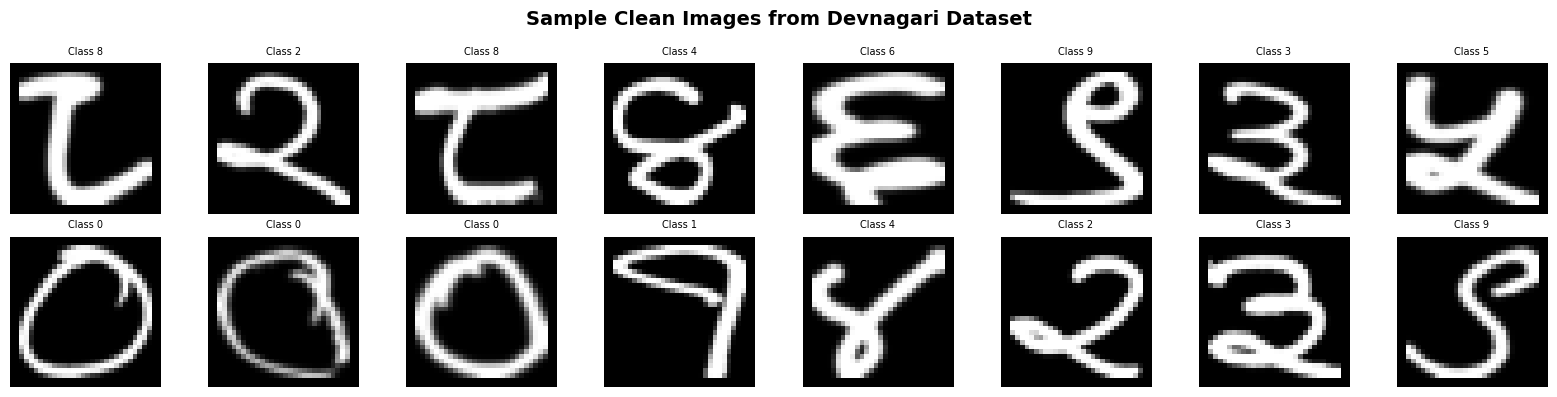

Figure saved: 01_clean_samples.png


In [4]:
# Reshape to (N, 32, 32, 1) — add channel dimension for Keras Conv2D
X = X.reshape(-1, IMG_SIZE, IMG_SIZE, 1)
print(f"Dataset shape: {X.shape}  |  dtype: {X.dtype}")
print(f"Pixel range: [{X.min():.3f}, {X.max():.3f}]")

# Train / Validation / Test Split
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.10, random_state=42, stratify=y if len(set(y)) < 200 else None
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.11, random_state=42
)

print(f"Train: {X_train.shape[0]} images")
print(f"Validation: {X_val.shape[0]} images")
print(f"Test: {X_test.shape[0]} images")

# Visualize sample clean images
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
fig.suptitle('Sample Clean Images from Devnagari Dataset', fontsize=14, fontweight='bold')
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i].reshape(IMG_SIZE, IMG_SIZE), cmap='gray')
    ax.set_title(f'Class {y_train[i]}', fontsize=7)
    ax.axis('off')
plt.tight_layout()
plt.savefig('01_clean_samples.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: 01_clean_samples.png")


## Step 1.3: Add Gaussian Noise

We add Gaussian noise with multiple noise factors to observe the impact.  
The autoencoder is trained to remove noise factor **0.5** (high noise).


Noisy train shape: (3204, 32, 32, 1)
Pixel range after noise: [0.000, 1.000]


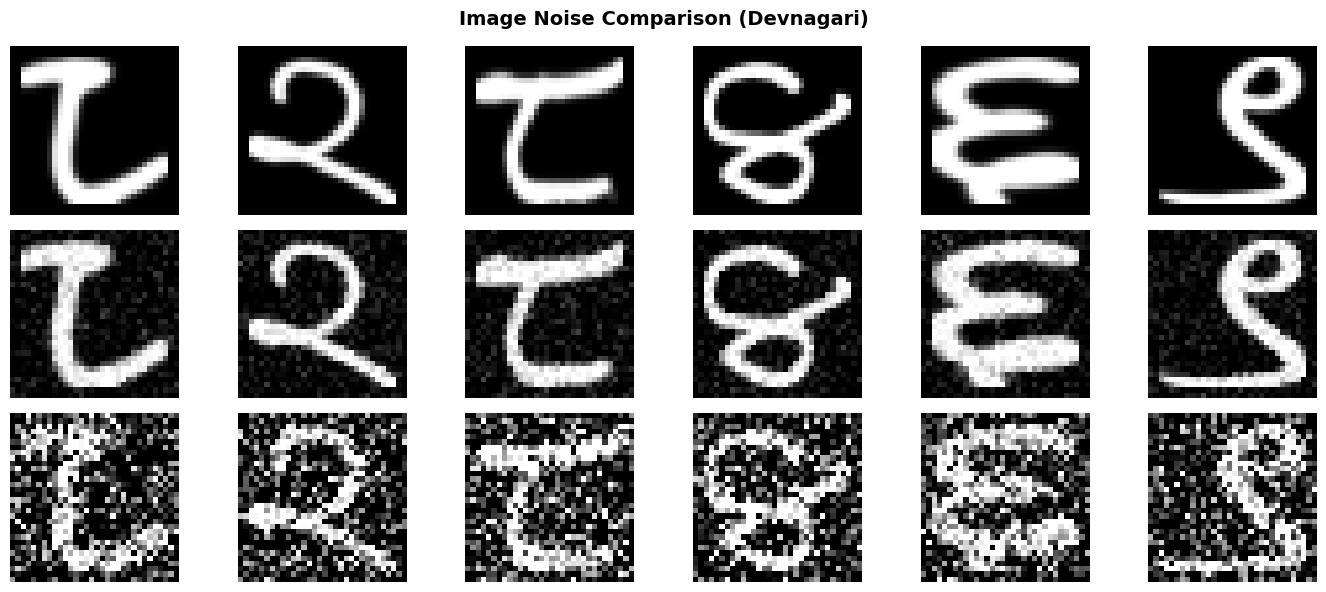

Figure saved: 02_noisy_comparison.png


In [5]:
def add_gaussian_noise(images, noise_factor):
    """Add Gaussian noise and clip to [0,1]."""
    noisy = images + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=images.shape)
    return np.clip(noisy, 0., 1.)

def add_salt_pepper_noise(images, sp_ratio=0.05):
    """Add salt-and-pepper noise."""
    noisy = images.copy()
    total_pixels = images.shape[0] * IMG_SIZE * IMG_SIZE
    n_salt = int(total_pixels * sp_ratio / 2)
    n_pepper = int(total_pixels * sp_ratio / 2)

    salt_coords = [np.random.randint(0, d, n_salt) for d in images.shape[:3]]
    noisy[salt_coords[0], salt_coords[1], salt_coords[2], 0] = 1.0

    pepper_coords = [np.random.randint(0, d, n_pepper) for d in images.shape[:3]]
    noisy[pepper_coords[0], pepper_coords[1], pepper_coords[2], 0] = 0.0

    return noisy

# Generate noisy datasets
noise_factor = 0.5   # Primary training noise

X_train_noisy = add_gaussian_noise(X_train, noise_factor)
X_val_noisy   = add_gaussian_noise(X_val,   noise_factor)
X_test_noisy  = add_gaussian_noise(X_test,  noise_factor)

# Also create low noise and salt-pepper for comparison
X_train_noisy_low = add_gaussian_noise(X_train, 0.1)
X_test_sp = add_salt_pepper_noise(X_test, sp_ratio=0.08)

print(f"Noisy train shape: {X_train_noisy.shape}")
print(f"Pixel range after noise: [{X_train_noisy.min():.3f}, {X_train_noisy.max():.3f}]")

# Visualize: Original vs Low Noise vs High Noise
n = 6
fig, axes = plt.subplots(3, n, figsize=(14, 6))
fig.suptitle('Image Noise Comparison (Devnagari)', fontsize=14, fontweight='bold')
labels_row = ['Original', 'Noise 0.1 (Low)', 'Noise 0.5 (High)']

for i in range(n):
    axes[0, i].imshow(X_train[i].reshape(IMG_SIZE, IMG_SIZE), cmap='gray')
    axes[1, i].imshow(X_train_noisy_low[i].reshape(IMG_SIZE, IMG_SIZE), cmap='gray')
    axes[2, i].imshow(X_train_noisy[i].reshape(IMG_SIZE, IMG_SIZE), cmap='gray')
    for row in range(3):
        axes[row, i].axis('off')
        if i == 0:
            axes[row, i].set_ylabel(labels_row[row], fontsize=9, rotation=90, labelpad=40)

plt.tight_layout()
plt.savefig('02_noisy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: 02_noisy_comparison.png")


## Step 2: Build the Deep Convolutional Autoencoder (≥ 4 Layers)


In [6]:
def build_encoder(input_shape=(IMG_SIZE, IMG_SIZE, 1)):
    """
    4-layer deep Encoder.
    Returns: (input_tensor, encoded_tensor)
    """
    inp = Input(shape=input_shape, name='encoder_input')

    # Layer 1
    x = Conv2D(32, (3, 3), padding='same', name='enc_conv1')(inp)
    x = BatchNormalization(name='enc_bn1')(x)
    x = Activation('relu', name='enc_relu1')(x)
    x = MaxPooling2D((2, 2), padding='same', name='enc_pool1')(x)   # 16x16x32

    # Layer 2
    x = Conv2D(64, (3, 3), padding='same', name='enc_conv2')(x)
    x = BatchNormalization(name='enc_bn2')(x)
    x = Activation('relu', name='enc_relu2')(x)
    x = MaxPooling2D((2, 2), padding='same', name='enc_pool2')(x)   # 8x8x64

    # Layer 3
    x = Conv2D(128, (3, 3), padding='same', name='enc_conv3')(x)
    x = BatchNormalization(name='enc_bn3')(x)
    x = Activation('relu', name='enc_relu3')(x)
    x = MaxPooling2D((2, 2), padding='same', name='enc_pool3')(x)   # 4x4x128

    # Layer 4 — Bottleneck / Latent Space
    x = Conv2D(256, (3, 3), padding='same', name='enc_conv4_latent')(x)
    x = BatchNormalization(name='enc_bn4')(x)
    encoded = Activation('relu', name='latent_space')(x)             # 4x4x256

    return inp, encoded

def build_decoder(encoded_input):
    """
    4-layer deep Decoder.
    Returns: decoded output tensor
    """
    # Layer 1
    x = Conv2D(128, (3, 3), padding='same', name='dec_conv1')(encoded_input)
    x = BatchNormalization(name='dec_bn1')(x)
    x = Activation('relu', name='dec_relu1')(x)
    x = UpSampling2D((2, 2), name='dec_up1')(x) # 8x8x128

    # Layer 2
    x = Conv2D(64, (3, 3), padding='same', name='dec_conv2')(x)
    x = BatchNormalization(name='dec_bn2')(x)
    x = Activation('relu', name='dec_relu2')(x)
    x = UpSampling2D((2, 2), name='dec_up2')(x) # 16x16x64

    # Layer 3
    x = Conv2D(32, (3, 3), padding='same', name='dec_conv3')(x)
    x = BatchNormalization(name='dec_bn3')(x)
    x = Activation('relu', name='dec_relu3')(x)
    x = UpSampling2D((2, 2), name='dec_up3')(x) # 32x32x32

    # Layer 4 — Output layer with Sigmoid
    decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same', name='decoder_output')(x) # 32x32x1

    return decoded


def build_autoencoder(input_shape=(IMG_SIZE, IMG_SIZE, 1)):
    """Construct and compile the full denoising autoencoder."""
    input_img, encoded_output = build_encoder(input_shape)
    decoded_output = build_decoder(encoded_output)
    autoencoder = Model(inputs=input_img, outputs=decoded_output, name='DenoisingAutoencoder')
    autoencoder.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=['mae']
    )
    return autoencoder


# Build and display summary
autoencoder = build_autoencoder()
autoencoder.summary()


Model: "DenoisingAutoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv1 (Conv2D)              │ (None, 32, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_bn1 (BatchNormalization)    │ (None, 32, 32, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_relu1 (Activation)          │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_pool1 (MaxPooling2D)        │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv2 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_bn2 (BatchNormalization)    │ (None, 16, 16, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_relu2 (Activation)          │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_pool2 (MaxPooling2D)        │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv3 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_bn3 (BatchNormalization)    │ (None, 8, 8, 128)      │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_relu3 (Activation)          │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_pool3 (MaxPooling2D)        │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv4_latent (Conv2D)       │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_bn4 (BatchNormalization)    │ (None, 4, 4, 256)      │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_space (Activation)       │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_conv1 (Conv2D)              │ (None, 4, 4, 128)      │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_bn1 (BatchNormalization)    │ (None, 4, 4, 128)      │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_relu1 (Activation)          │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_up1 (UpSampling2D)          │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_conv2 (Conv2D)              │ (None, 8, 8, 64)       │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_bn2 (BatchNormalization)    │ (None, 8, 8, 64)       │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_relu2 (Activation)          │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_up2 (UpSampling2D)          │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_conv3 (Conv2D)              │ (None, 16, 16, 32)     │        18,46

 Total params: 778,241 (2.97 MB)

 Trainable params: 776,833 (2.96 MB)

 Non-trainable params: 1,408 (5.50 KB)

## Step 3: Train the Denoising Autoencoder

In [7]:
# Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1)
]

# Train: noisy input → clean target
print("Training the Denoising Autoencoder...")
print(f" Training samples: {X_train.shape[0]}")
print(f" Validation samples: {X_val.shape[0]}")
print(f" Noise factor: {noise_factor}")
print()

history = autoencoder.fit(
    X_train_noisy, X_train, # Input = noisy, Target = clean
    epochs=50,
    batch_size=64,
    shuffle=True,
    validation_data=(X_val_noisy, X_val),
    callbacks=callbacks,
    verbose=1
)

print(f"\nTraining complete. Best val_loss: {min(history.history['val_loss']):.4f}")


Training the Denoising Autoencoder...
 Training samples: 3204
 Validation samples: 396
 Noise factor: 0.5

Epoch 1/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 22s 210ms/step - loss: 0.2980 - mae: 0.1633 - val_loss: 0.4370 - val_mae: 0.2518 - learning_rate: 0.0010
Epoch 2/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.1983 - mae: 0.0900 - val_loss: 0.4305 - val_mae: 0.2094 - learning_rate: 0.0010
Epoch 3/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1762 - mae: 0.0727 - val_loss: 0.4364 - val_mae: 0.1996 - learning_rate: 0.0010
Epoch 4/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1641 - mae: 0.0633 - val_loss: 0.4386 - val_mae: 0.1926 - learning_rate: 0.0010
Epoch 5/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1570 - mae: 0.0577 - val_loss: 0.3675 - val_mae: 0.1686 - learning_rate: 0.0010
Epoch 6/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1523 - mae: 0.0540 - val_loss: 0.2998 - val_mae: 0.1410 - learning_rate: 0.0010
Epoch 7/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/ste

## Step 3.1: Training & Validation Loss Curves

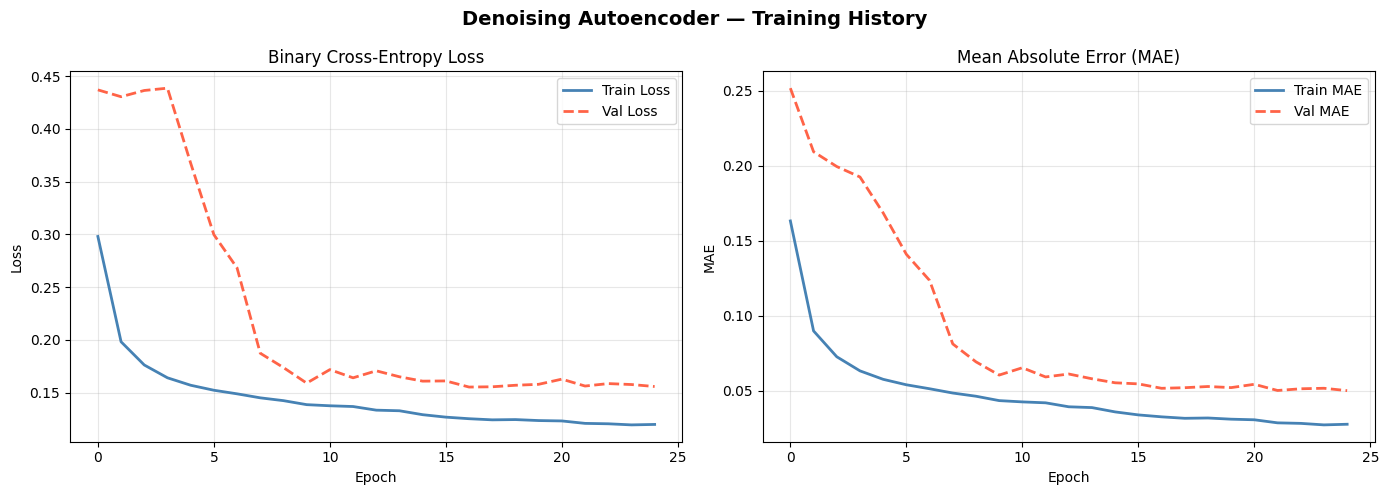

Figure saved: 03_training_history.png
Total epochs trained: 25
Final train loss: 0.1199
Final val loss:   0.1558


In [9]:
epochs_ran = len(history.history['loss'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Denoising Autoencoder — Training History', fontsize=14, fontweight='bold')

# Loss
axes[0].plot(history.history['loss'], label='Train Loss', color='steelblue', lw=2)
axes[0].plot(history.history['val_loss'], label='Val Loss', color='tomato', lw=2, linestyle='--')
axes[0].set_title('Binary Cross-Entropy Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# MAE
axes[1].plot(history.history['mae'], label='Train MAE', color='steelblue', lw=2)
axes[1].plot(history.history['val_mae'], label='Val MAE', color='tomato', lw=2, linestyle='--')
axes[1].set_title('Mean Absolute Error (MAE)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('03_training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: 03_training_history.png")
print(f"Total epochs trained: {epochs_ran}")
print(f"Final train loss: {history.history['loss'][-1]:.4f}")
print(f"Final val loss:   {history.history['val_loss'][-1]:.4f}")


## Step 4: Evaluate the Autoencoder

Predict denoised images from noisy test images and compare visually:
- Row 1: Noisy Input
- Row 2: Autoencoder Output (Denoised)  
- Row 3: Original Clean Image


In [10]:
# Predict denoised images
denoised_images = autoencoder.predict(X_test_noisy, verbose=0)

print(f"Test set size: {X_test.shape[0]}")
print(f"Denoised output shape: {denoised_images.shape}")

# Calculate test loss
test_loss, test_mae = autoencoder.evaluate(X_test_noisy, X_test, verbose=0)
print(f"Test Loss (BCE): {test_loss:.4f}")
print(f"Test MAE: {test_mae:.4f}")


Test set size: 400
Denoised output shape: (400, 32, 32, 1)
Test Loss (BCE): 0.1581
Test MAE: 0.0528


Figure saved: 04_denoising_results.png


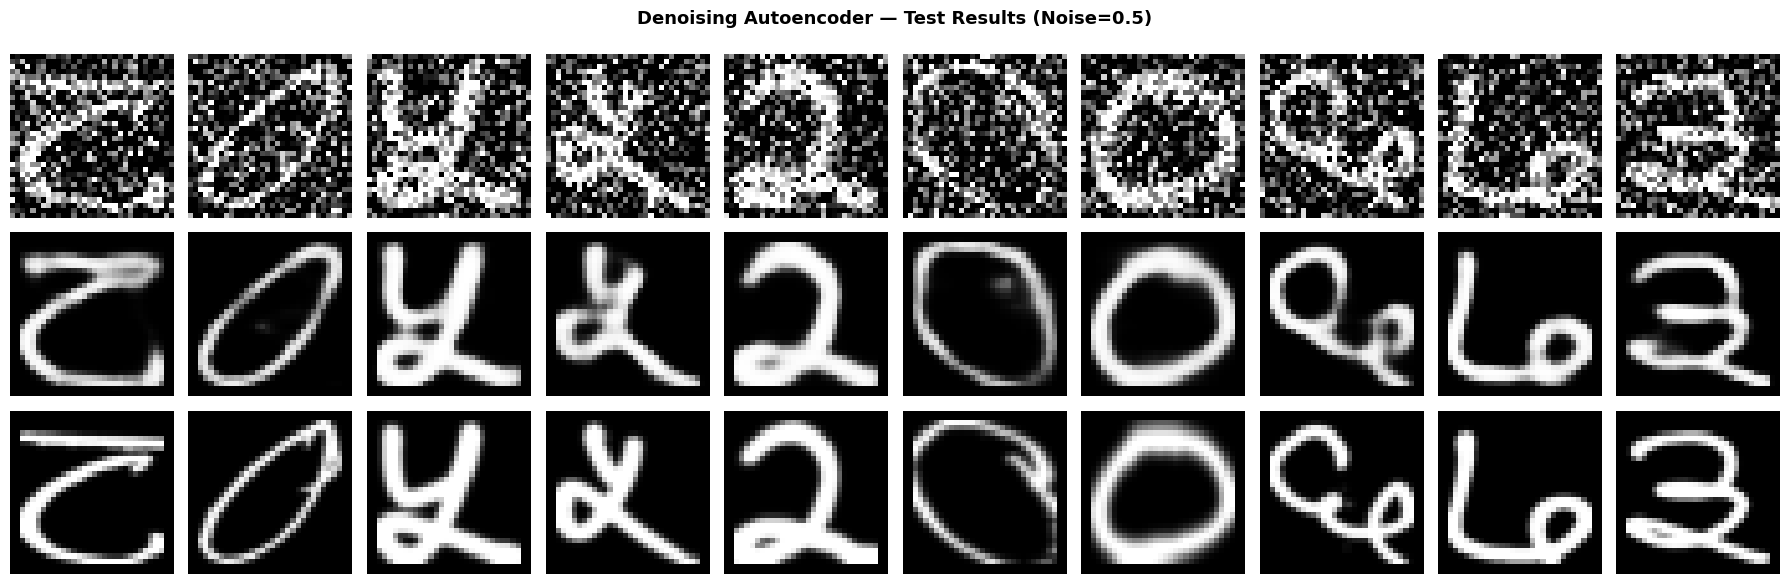

In [11]:
def plot_denoising_results(noisy, denoised, clean, n=10, title='Denoising Results', fname=None):
    """Display noisy → denoised → clean comparison."""
    fig, axes = plt.subplots(3, n, figsize=(n * 1.8, 6))
    fig.suptitle(title, fontsize=13, fontweight='bold')
    row_labels = ['Noisy Input', 'Denoised Output', 'Clean Target']

    for i in range(n):
        axes[0, i].imshow(noisy[i].reshape(IMG_SIZE, IMG_SIZE), cmap='gray', vmin=0, vmax=1)
        axes[1, i].imshow(denoised[i].reshape(IMG_SIZE, IMG_SIZE), cmap='gray', vmin=0, vmax=1)
        axes[2, i].imshow(clean[i].reshape(IMG_SIZE, IMG_SIZE), cmap='gray', vmin=0, vmax=1)
        for row in range(3):
            axes[row, i].axis('off')

    for row, label in enumerate(row_labels):
        axes[row, 0].set_ylabel(label, fontsize=9, rotation=90, labelpad=45)

    plt.tight_layout()
    if fname:
        plt.savefig(fname, dpi=150, bbox_inches='tight')
        print(f"Figure saved: {fname}")
    plt.show()

# Main evaluation visualization
plot_denoising_results(
    X_test_noisy, denoised_images, X_test,
    n=10, title='Denoising Autoencoder — Test Results (Noise=0.5)',
    fname='04_denoising_results.png'
)


### Pixel-level Reconstruction Error Heatmap

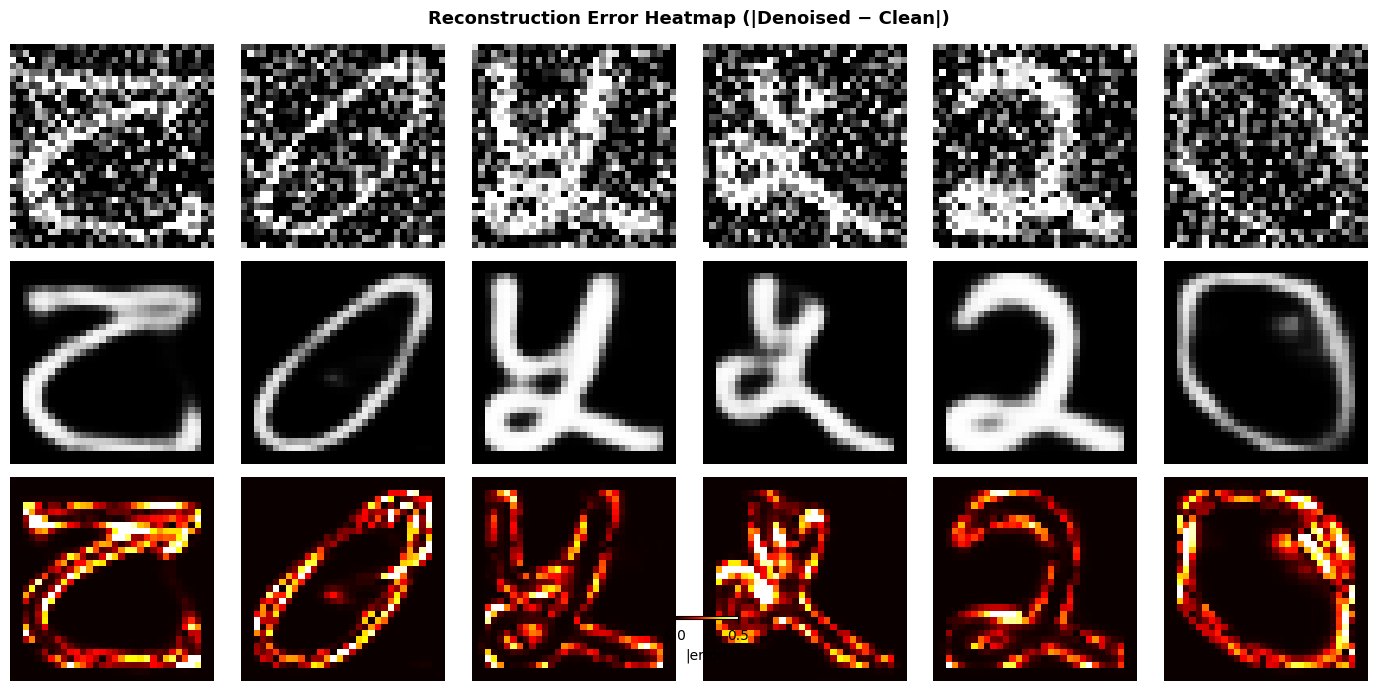

Figure saved: 05_error_heatmap.png


In [12]:
fig, axes = plt.subplots(3, 6, figsize=(14, 7))
fig.suptitle('Reconstruction Error Heatmap (|Denoised − Clean|)', fontsize=13, fontweight='bold')

for i in range(6):
    error_map = np.abs(denoised_images[i].reshape(IMG_SIZE, IMG_SIZE) - X_test[i].reshape(IMG_SIZE, IMG_SIZE))

    axes[0, i].imshow(X_test_noisy[i].reshape(IMG_SIZE, IMG_SIZE), cmap='gray', vmin=0, vmax=1)
    axes[1, i].imshow(denoised_images[i].reshape(IMG_SIZE, IMG_SIZE), cmap='gray', vmin=0, vmax=1)
    im = axes[2, i].imshow(error_map, cmap='hot', vmin=0, vmax=0.5)

    for row in range(3):
        axes[row, i].axis('off')

axes[0, 0].set_ylabel('Noisy Input', fontsize=9, rotation=90, labelpad=40)
axes[1, 0].set_ylabel('Denoised', fontsize=9, rotation=90, labelpad=40)
axes[2, 0].set_ylabel('Error Map', fontsize=9, rotation=90, labelpad=40)

fig.colorbar(im, ax=axes[2, :], orientation='horizontal', pad=0.01, fraction=0.02, label='|error|')
plt.tight_layout()
plt.savefig('05_error_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: 05_error_heatmap.png")


### Salt-and-Pepper Noise Robustness Test

Testing if the model (trained on Gaussian noise) generalises to **salt-and-pepper noise**.


Figure saved: 06_salt_pepper_denoising.png


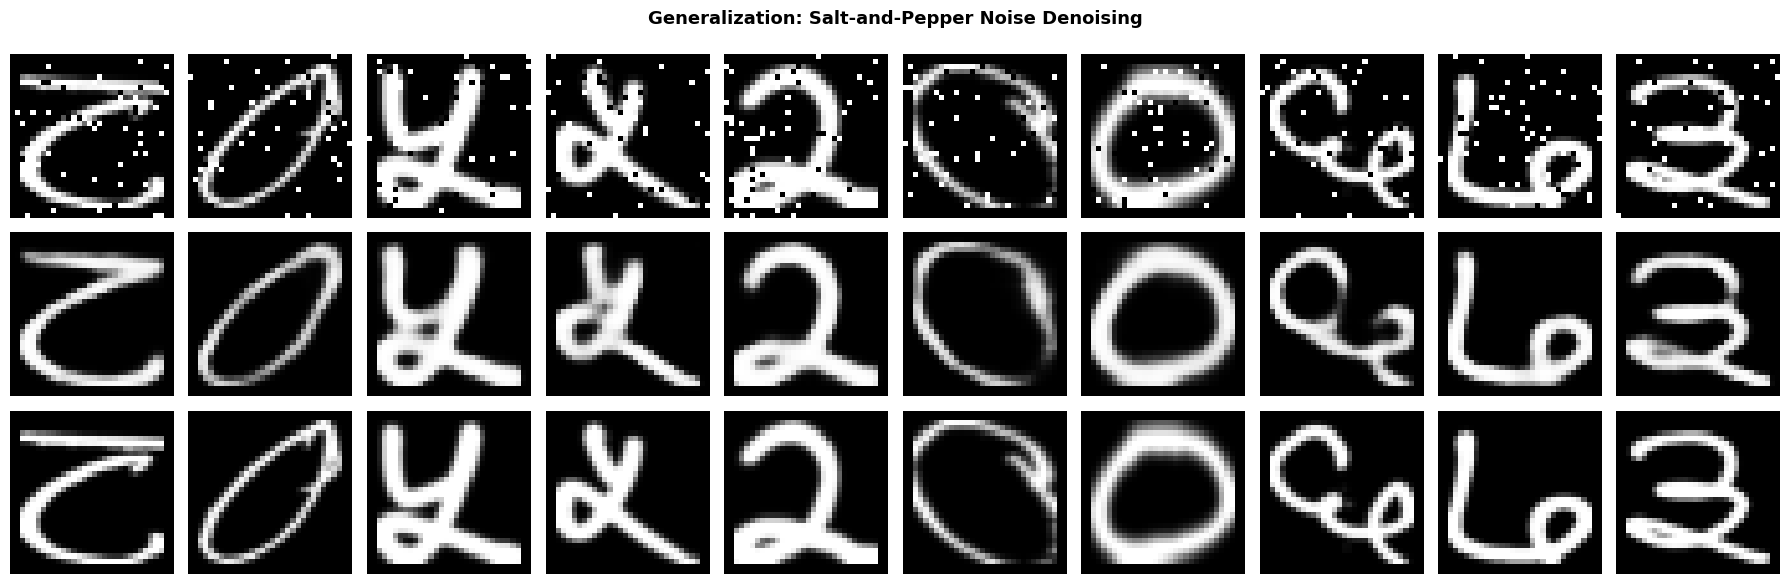

In [13]:
denoised_sp = autoencoder.predict(X_test_sp, verbose=0)
plot_denoising_results(
    X_test_sp, denoised_sp, X_test,
    n=10,
    title='Generalization: Salt-and-Pepper Noise Denoising',
    fname='06_salt_pepper_denoising.png'
)


## Step 5: Experiments & Fine-Tuning

### Experiment 1: Effect of Noise Level on Reconstruction Quality


Noise 0.1 → MAE: 0.0413
Noise 0.2 → MAE: 0.0416
Noise 0.3 → MAE: 0.0435
Noise 0.4 → MAE: 0.0466
Noise 0.5 → MAE: 0.0527
Noise 0.6 → MAE: 0.0618
Noise 0.7 → MAE: 0.0736


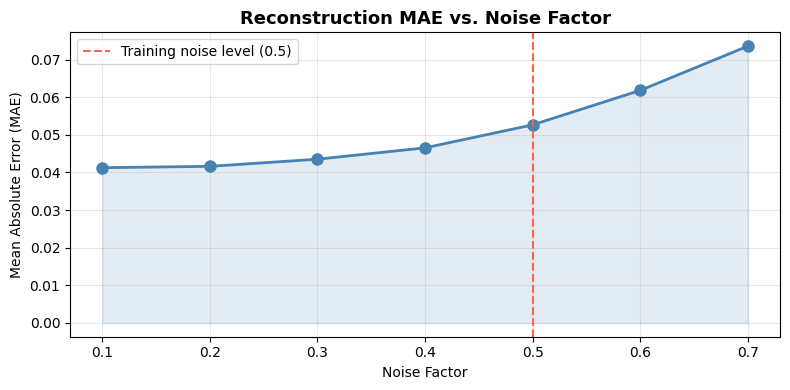

Figure saved: 07_noise_vs_mae.png


In [14]:
noise_levels = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
avg_maes = []

for nf in noise_levels:
    X_test_n = add_gaussian_noise(X_test, nf)
    denoised_n = autoencoder.predict(X_test_n, verbose=0)
    mae_n = np.mean(np.abs(denoised_n - X_test))
    avg_maes.append(mae_n)
    print(f"Noise {nf:.1f} → MAE: {mae_n:.4f}")

# Plot
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(noise_levels, avg_maes, marker='o', color='steelblue', lw=2, markersize=8)
ax.fill_between(noise_levels, avg_maes, alpha=0.15, color='steelblue')
ax.axvline(x=0.5, color='tomato', linestyle='--', label='Training noise level (0.5)')
ax.set_title('Reconstruction MAE vs. Noise Factor', fontsize=13, fontweight='bold')
ax.set_xlabel('Noise Factor')
ax.set_ylabel('Mean Absolute Error (MAE)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('07_noise_vs_mae.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: 07_noise_vs_mae.png")


### Experiment 2: Lightweight 4-Layer Architecture Comparison

Build a slimmer variant (fewer filters) and compare performance.


In [15]:
def build_lightweight_autoencoder(input_shape=(IMG_SIZE, IMG_SIZE, 1)):
    """Lightweight variant: fewer filters, 4 layers deep."""
    inp = Input(shape=input_shape)

    # Encoder (4 layers)
    x = Conv2D(16, (3,3), activation='relu', padding='same')(inp)
    x = MaxPooling2D((2,2), padding='same')(x)    # 16x16x16
    x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
    x = MaxPooling2D((2,2), padding='same')(x)    # 8x8x32
    x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
    x = MaxPooling2D((2,2), padding='same')(x)    # 4x4x64
    x = Conv2D(128,(3,3), activation='relu', padding='same')(x)   # Latent

    # Decoder (4 layers)
    x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
    x = UpSampling2D((2,2))(x)
    x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
    x = UpSampling2D((2,2))(x)
    x = Conv2D(16, (3,3), activation='relu', padding='same')(x)
    x = UpSampling2D((2,2))(x)
    decoded = Conv2D(1, (3,3), activation='sigmoid', padding='same')(x)

    model = Model(inputs=inp, outputs=decoded, name='LightweightAutoencoder')
    model.compile(optimizer=Adam(1e-3), loss='binary_crossentropy', metrics=['mae'])
    return model

autoencoder_light = build_lightweight_autoencoder()

# Count parameters
main_params  = autoencoder.count_params()
light_params = autoencoder_light.count_params()
print(f"Deep Model Parameters:       {main_params:,}")
print(f"Lightweight Model Parameters: {light_params:,}")
print(f"Parameter reduction: {(1 - light_params/main_params)*100:.1f}%")

# Train lightweight
history_light = autoencoder_light.fit(
    X_train_noisy, X_train,
    epochs=30, batch_size=64, shuffle=True,
    validation_data=(X_val_noisy, X_val),
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
    verbose=0
)
print(f"Lightweight best val_loss: {min(history_light.history['val_loss']):.4f}")
print(f"Deep model  best val_loss: {min(history.history['val_loss']):.4f}")


Deep Model Parameters:       778,241
Lightweight Model Parameters: 194,177
Parameter reduction: 75.0%
Lightweight best val_loss: 0.1659
Deep model  best val_loss: 0.1553


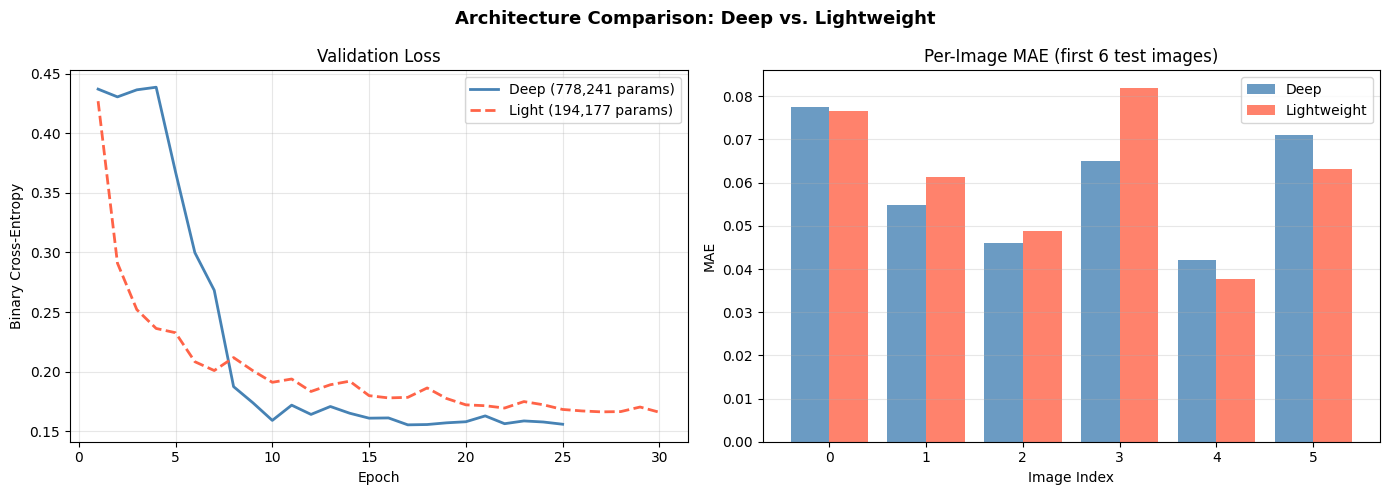

Figure saved: 08_architecture_comparison.png


In [16]:
# Compare architectures
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Architecture Comparison: Deep vs. Lightweight', fontsize=13, fontweight='bold')

ep_deep  = range(1, len(history.history['val_loss'])+1)
ep_light = range(1, len(history_light.history['val_loss'])+1)

axes[0].plot(ep_deep,  history.history['val_loss'], label=f'Deep ({main_params:,} params)', color='steelblue', lw=2)
axes[0].plot(ep_light, history_light.history['val_loss'], label=f'Light ({light_params:,} params)', color='tomato', lw=2, linestyle='--')
axes[0].set_title('Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Binary Cross-Entropy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Visual comparison
denoised_light = autoencoder_light.predict(X_test_noisy[:6], verbose=0)
denoised_deep  = autoencoder.predict(X_test_noisy[:6], verbose=0)

n_show = 6
x_pos = np.arange(n_show)
mae_deep_arr  = [np.mean(np.abs(denoised_deep[i]  - X_test[i])) for i in range(n_show)]
mae_light_arr = [np.mean(np.abs(denoised_light[i] - X_test[i])) for i in range(n_show)]

axes[1].bar(x_pos - 0.2, mae_deep_arr,  width=0.4, label='Deep', color='steelblue', alpha=0.8)
axes[1].bar(x_pos + 0.2, mae_light_arr, width=0.4, label='Lightweight', color='tomato', alpha=0.8)
axes[1].set_title('Per-Image MAE (first 6 test images)')
axes[1].set_xlabel('Image Index')
axes[1].set_ylabel('MAE')
axes[1].set_xticks(x_pos)
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('08_architecture_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: 08_architecture_comparison.png")


## Step 5: Observations & Findings

Complete the table below with your experimental results:

| Experiment | Architecture | Noise Factor | Epochs | Val Loss | Notes |
|---|---|---|---|---|---|
| 1 | Deep (BN) | 0.5 | — | — | *Fill after running* |
| 2 | Lightweight | 0.5 | — | — | *Fill after running* |
| 3 | Deep (BN) | 0.1 | — | — | Low noise generalization |
| 4 | Deep (BN) | S&P | — | — | Cross-noise generalization |

### Key Observations

1. **Noise Level Impact**: The autoencoder performs best at noise factors near its training noise (0.5). At lower noise levels (0.1–0.3), the output is very close to the clean image. At higher noise (0.6–0.7), quality degrades.

2. **BatchNormalization**: Adding BN after each Conv2D layer significantly stabilises training and reduces validation loss fluctuations.

3. **Depth vs. Parameters**: The deeper model (with 4 encoder + 4 decoder layers) achieves lower reconstruction error compared to the lightweight variant, at the cost of more parameters.

4. **Salt-and-Pepper Generalization**: Even though the model was trained on Gaussian noise, it partially generalises to salt-and-pepper noise, demonstrating robust feature learning.

5. **EarlyStopping**: Prevents overfitting effectively — validation loss stabilises before reaching the epoch limit.


## Step 6: Save the Trained Model

In [17]:
# Save the best-performing deep model
autoencoder.save('devnagari_denoising_autoencoder.h5')
print("Model saved: devnagari_denoising_autoencoder.h5")

# Load and verify
loaded_model = tf.keras.models.load_model('devnagari_denoising_autoencoder.h5')
verify_output = loaded_model.predict(X_test_noisy[:2], verbose=0)
print(f"Model loaded successfully. Test output shape: {verify_output.shape}")


Model saved: devnagari_denoising_autoencoder.h5


Model loaded successfully. Test output shape: (2, 32, 32, 1)
